# Hurricane Otis (2023) — AI Model Track Comparison

Compare tropical cyclone tracks from **GraphCast**, **AIFS**, and **FCN3**
against ERA5 reanalysis for Hurricane Otis, at three lead times before
landfall (T−72 h, T−168 h, T−240 h).

**Verification target:** Otis landfall near Acapulco, Guerrero, Mexico,
snapped to `2023-10-25 06:00 UTC`.

| Lead  | Init time (UTC)  | Steps (6 h) |
|-------|------------------|-------------|
| 72 h  | 2023-10-22 06:00 | 12          |
| 168 h | 2023-10-18 06:00 | 28          |
| 240 h | 2023-10-15 06:00 | 40          |

In [1]:
import os

os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"
# Prevent JAX from pre-allocating all GPU memory (needed for GraphCast + PyTorch coexistence).
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

from earth2studio.models.px import AIFS, GraphCastOperational
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import ARCO, CDS, fetch_data, prep_data_array
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/jovyan/hurricane-forecasts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


 parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failed
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


Device: cuda
GPU   : NVIDIA L40
VRAM  : 47.7 GB


In [3]:
STORM_NAME        = "Otis"
VERIFICATION_TIME = datetime(2023, 10, 25, 6)
LEAD_TIMES_H      = [72, 168, 240]

INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

OUT_DIR      = Path("./outputs/otis")
PLOT_EXTENT  = (-120, -85, 5, 25)
LANDFALL_LAT = 16.8
LANDFALL_LON = -99.9

MODEL_COLORS = {
    "AIFS":      "#2ca02c",
    "GraphCast": "#1f77b4",
    "ERA5":      "#000000",
}

OUT_DIR.mkdir(parents=True, exist_ok=True)

for h in LEAD_TIMES_H:
    print(f"  T-{h:>3}h : init={INIT_TIMES[h]}  steps={N_STEPS[h]}")

  T- 72h : init=2023-10-22 06:00:00  steps=12
  T-168h : init=2023-10-18 06:00:00  steps=28
  T-240h : init=2023-10-15 06:00:00  steps=40


In [4]:
def run_tc_inference(prognostic, data_source, start_time, nsteps, save_path):
    """Run a prognostic model through TCTrackerWuDuan and cache the track tensor."""
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    prognostic = prognostic.to(DEVICE)
    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}")
    return tracks

In [5]:
def run_era5_truth(data_source, start_time, nsteps, save_path):
    """Track ERA5 reanalysis with TCTrackerWuDuan over the same time window as a forecast."""
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
    for time in tqdm(times):
        try:
            da = data_source(time, tracker.input_coords()["variable"])
        except RuntimeError:
            # Corrupted cache chunk — retry with a fresh uncached download.
            from earth2studio.data import ARCO
            da = ARCO(cache=False)(time, tracker.input_coords()["variable"])
        x, coords = prep_data_array(da, device=DEVICE)
        output, _ = tracker(x, coords)

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}")
    return tracks

In [6]:
# ARCO provides ERA5 through Oct 2023; WB2ERA5 has a hard cutoff at 2023-01-11.
data_source = ARCO(cache=True)

In [7]:
aifs_data_source = CDS(cache=True)

## AIFS forecasts

In [8]:
%%time
aifs = AIFS.load_model(AIFS.load_default_package())

CPU times: user 5.45 s, sys: 673 ms, total: 6.13 s
Wall time: 6.07 s


In [9]:
%%time
aifs_tracks_72 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "aifs_72h.pt",
)

  cached → outputs/otis/aifs_72h.pt
CPU times: user 1.5 ms, sys: 39 μs, total: 1.54 ms
Wall time: 1.84 ms


In [10]:
%%time
aifs_tracks_168 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "aifs_168h.pt",
)

  cached → outputs/otis/aifs_168h.pt
CPU times: user 1.06 ms, sys: 5 μs, total: 1.06 ms
Wall time: 874 μs


In [11]:
%%time
aifs_tracks_240 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "aifs_240h.pt",
)

  cached → outputs/otis/aifs_240h.pt
CPU times: user 952 μs, sys: 0 ns, total: 952 μs
Wall time: 796 μs


In [12]:
import gc
del aifs
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## GraphCast forecasts

GraphCast (Google DeepMind) — autoregressive GNN on an icosahedral multi-mesh.
Uses JAX under the hood; `XLA_PYTHON_CLIENT_PREALLOCATE=false` prevents it from
grabbing all GPU memory before PyTorch can use it.

In [13]:
%%time
graphcast = GraphCastOperational.load_model(GraphCastOperational.load_default_package())

CPU times: user 386 ms, sys: 746 ms, total: 1.13 s
Wall time: 21.9 s


In [14]:
%%time
gc_tracks_72 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "graphcast_72h.pt",
)

  cached → outputs/otis/graphcast_72h.pt
CPU times: user 1.36 ms, sys: 0 ns, total: 1.36 ms
Wall time: 1.34 ms


In [15]:
%%time
gc_tracks_168 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "graphcast_168h.pt",
)

  cached → outputs/otis/graphcast_168h.pt
CPU times: user 1.19 ms, sys: 21 μs, total: 1.21 ms
Wall time: 1.26 ms


In [16]:
%%time
gc_tracks_240 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "graphcast_240h.pt",
)

  cached → outputs/otis/graphcast_240h.pt
CPU times: user 751 μs, sys: 80 μs, total: 831 μs
Wall time: 685 μs


In [17]:
del graphcast
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved

## ERA5 truth tracks

In [18]:
%%time
era5_tracks_72 = run_era5_truth(
    data_source, INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "era5_72h.pt",
)

  cached → outputs/otis/era5_72h.pt
CPU times: user 1.22 ms, sys: 24 μs, total: 1.25 ms
Wall time: 1.01 ms


In [19]:
%%time
era5_tracks_168 = run_era5_truth(
    data_source, INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "era5_168h.pt",
)

  0%|                                                                                                            | 0/29 [00:00<?, ?it/s]

  0%|                                                                                                            | 0/29 [00:00<?, ?it/s]

2026-05-19 21:54:09.988 | DEBUG    | earth2studio.data.arco:_async_init:125 - Using Multi-Storage Client for ARCO data access


  0%|                                                                                                            | 0/29 [00:00<?, ?it/s]

2026-05-19 21:54:10.374 | DEBUG    | earth2studio.data.utils:_make_local_details:1066 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/.zattrs to local cache


...

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.11it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.07it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [01:02<00:00,  2.27s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [01:02<00:00,  2.15s/it]

  saved  → outputs/otis/era5_168h.pt
CPU times: user 15.3 s, sys: 22.9 s, total: 38.3 s
Wall time: 1min 2s


In [20]:
%%time
era5_tracks_240 = run_era5_truth(
    data_source, INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "era5_240h.pt",
)

  0%|                                                                                                            | 0/41 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

  0%|                                                                                                            | 0/41 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

...

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.22it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.23it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:38<00:00,  1.82it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:38<00:00,  1.05it/s]

  saved  → outputs/otis/era5_240h.pt
CPU times: user 14.2 s, sys: 21 s, total: 35.2 s
Wall time: 38.9 s


## Load saved tracks
Reload-safe: works whether you just ran inference or restarted the kernel.

In [21]:
# Reload all .pt files — safe to re-run after a kernel restart.
aifs_tracks_72  = torch.load(OUT_DIR / "aifs_72h.pt",  map_location="cpu")
aifs_tracks_168 = torch.load(OUT_DIR / "aifs_168h.pt", map_location="cpu")
aifs_tracks_240 = torch.load(OUT_DIR / "aifs_240h.pt", map_location="cpu")

era5_tracks_72  = torch.load(OUT_DIR / "era5_72h.pt",  map_location="cpu")
era5_tracks_168 = torch.load(OUT_DIR / "era5_168h.pt", map_location="cpu")
era5_tracks_240 = torch.load(OUT_DIR / "era5_240h.pt", map_location="cpu")

gc_tracks_72  = torch.load(OUT_DIR / "graphcast_72h.pt",  map_location="cpu")
gc_tracks_168 = torch.load(OUT_DIR / "graphcast_168h.pt", map_location="cpu")
gc_tracks_240 = torch.load(OUT_DIR / "graphcast_240h.pt", map_location="cpu")

print(f"AIFS  T-72h : {aifs_tracks_72.shape}")
print(f"ERA5  T-72h : {era5_tracks_72.shape}")
print(f"GCast T-72h : {gc_tracks_72.shape}")

AIFS  T-72h : torch.Size([1, 18, 13, 4])
ERA5  T-72h : torch.Size([1, 22, 13, 4])
GCast T-72h : torch.Size([1, 19, 13, 4])


## Track comparison maps

In [22]:
def plot_tracks(models_list, extent, title, save_path=None):
    """Plot TC tracks on a Cartopy map. ERA5 solid, forecasts dashed; markers sized by 10-m wind."""
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(11, 7),
    )

    ax.add_feature(cfeature.LAND,      facecolor="#e8e8e8", zorder=1)
    ax.add_feature(cfeature.OCEAN,     facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.3, linestyle=":", edgecolor="0.5", zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor="0.4", zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    for m in models_list:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        ls = "-"  if m["name"].startswith("ERA5") else "--"
        lw = 2.2  if m["name"].startswith("ERA5") else 1.8
        label_used = False

        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1] - 360.0
            w10m = tracks[0, p, :, 3]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() < 2:
                continue

            idx = np.where(mask)[0]
            lv, lnv, wv = lats[idx], lons[idx], w10m[idx]

            ax.plot(
                lnv, lv, color=m["color"], linewidth=lw, linestyle=ls,
                label=m["name"] if not label_used else "",
                transform=ccrs.PlateCarree(), zorder=5,
            )
            label_used = True

            sizes = np.clip(wv * 3.5, 15, 160)
            ax.scatter(
                lnv, lv, s=sizes, color=m["color"],
                edgecolors="white", linewidths=0.5,
                transform=ccrs.PlateCarree(), zorder=6,
            )

            for i, sz in [(0, 70), (-1, 90)]:
                ax.scatter(
                    lnv[i], lv[i], s=sz,
                    facecolors="none", edgecolors=m["color"], linewidths=1.6,
                    transform=ccrs.PlateCarree(), zorder=7,
                )

    ax.plot(
        LANDFALL_LON, LANDFALL_LAT,
        marker="*", color="#d62728", markersize=16,
        markeredgecolor="white", markeredgewidth=0.8,
        linestyle="None", label="Observed landfall",
        transform=ccrs.PlateCarree(), zorder=10,
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9, edgecolor="0.7", handlelength=2.5)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    fig.tight_layout()

    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight")
        print(f"saved → {save_path}")
    plt.show()

In [23]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Inputs in degrees, broadcasts with numpy."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def select_tc_path(track_tensor):
    """Return the path whose final position is closest to the known landfall point."""
    if hasattr(track_tensor, "numpy"):
        track_tensor = track_tensor.numpy()
    tracks = track_tensor[0]
    final_lats = tracks[:, -1, 0]
    final_lons = tracks[:, -1, 1]
    landfall_lon_360 = LANDFALL_LON % 360
    dists = haversine_km(final_lats, final_lons, LANDFALL_LAT, landfall_lon_360)
    return tracks[int(np.nanargmin(dists))]


def make_error_table(lead_h, models_dict):
    """Km-error table vs ERA5 truth; only rows where ERA5 has an active detection."""
    init_time  = INIT_TIMES[lead_h]
    era5_path  = select_tc_path(models_dict["ERA5 (truth)"])
    T          = era5_path.shape[0]

    model_paths = {
        name: select_tc_path(tensor)
        for name, tensor in models_dict.items()
        if name != "ERA5 (truth)"
    }

    rows = []
    for t in range(T):
        era_lat = era5_path[t, 0]
        era_lon = era5_path[t, 1]
        if np.isnan(era_lat):
            continue
        valid = init_time + timedelta(hours=6 * t)
        row = {"Valid (UTC)": valid.strftime("%m-%d %HZ")}
        for name, path in model_paths.items():
            m_lat = path[t, 0]
            m_lon = path[t, 1]
            km    = haversine_km(era_lat, era_lon, m_lat, m_lon)
            short = name.split()[0]
            row[f"{short} err (km)"] = "--" if np.isnan(km) else f"{km:.0f}"
        rows.append(row)

    return pd.DataFrame(rows)

saved → outputs/otis/track_72h.png


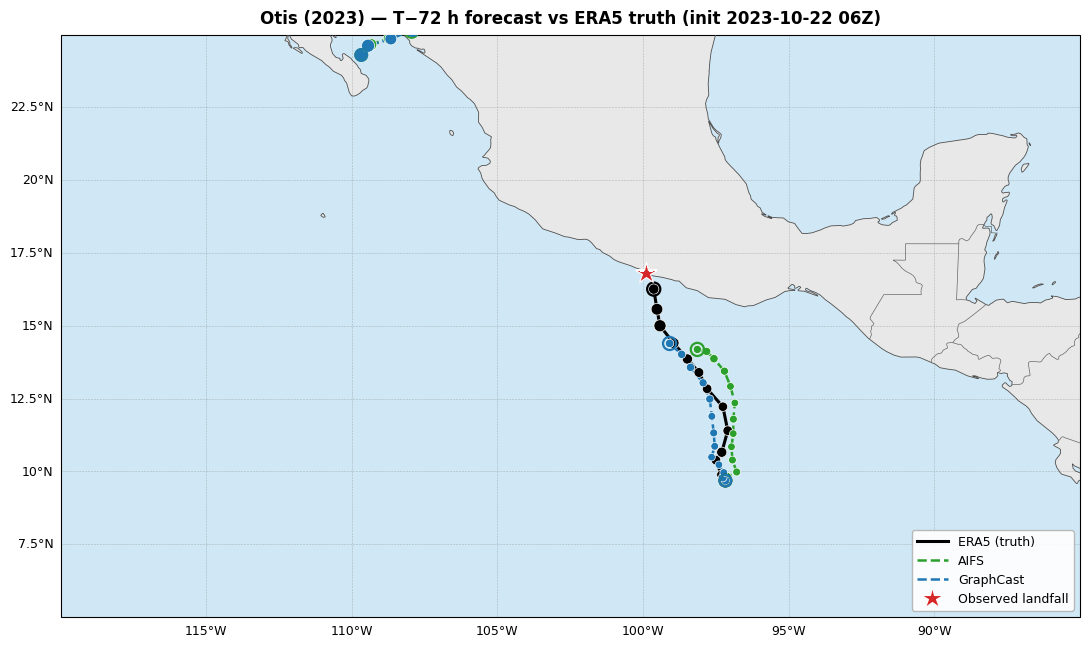

In [24]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_72, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_72, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_72,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2023) — T−72 h forecast vs ERA5 truth (init {INIT_TIMES[72]:%Y-%m-%d %H}Z)",
    save_path=OUT_DIR / "track_72h.png",
)

In [25]:
df_72 = make_error_table(72, {
    "ERA5 (truth)": era5_tracks_72,
    "AIFS":         aifs_tracks_72,
    "GraphCast":    gc_tracks_72,
})
print(f"\n=== T−72h position error (km) vs ERA5 truth ===\n")
print(df_72.to_string(index=False))


=== T−72h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-22 06Z             0                  0
  10-22 12Z            23                 12
  10-22 18Z            90                 56
  10-23 00Z            50                 49
  10-23 06Z            63                118
  10-23 12Z           110                154
  10-23 18Z           152                170
  10-24 00Z           177                174
  10-24 06Z           191                174
  10-24 12Z           218                188
  10-24 18Z           236                195
  10-25 00Z           244                195
  10-25 06Z           281                216


saved → outputs/otis/track_168h.png


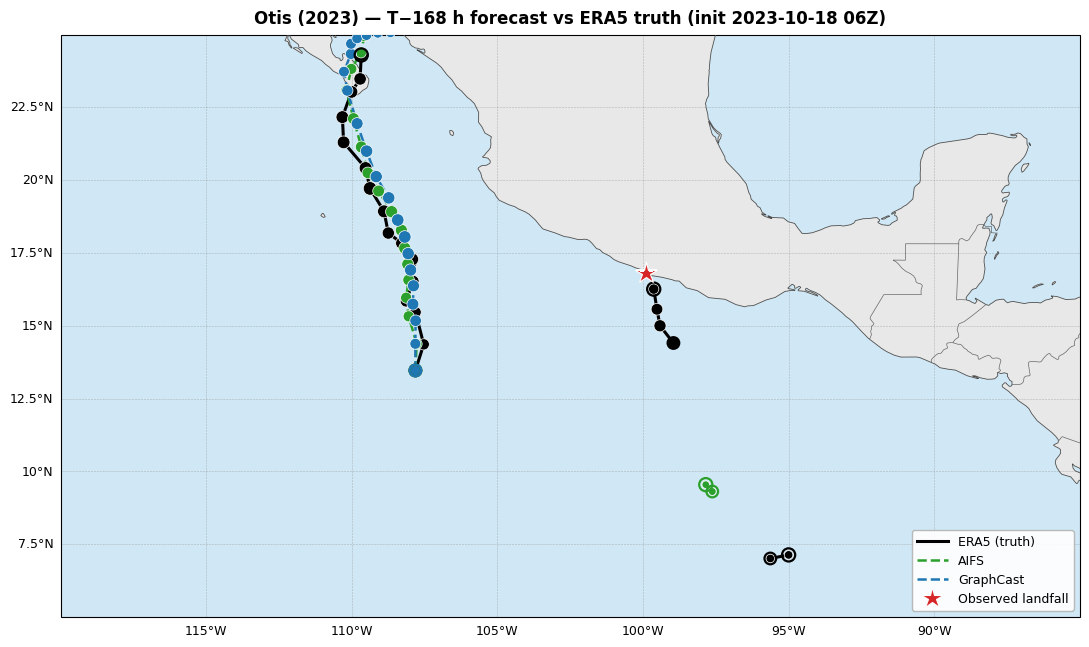

In [26]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_168, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_168, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_168,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2023) — T−168 h forecast vs ERA5 truth (init {INIT_TIMES[168]:%Y-%m-%d %H}Z)",
    save_path=OUT_DIR / "track_168h.png",
)

In [27]:
df_168 = make_error_table(168, {
    "ERA5 (truth)": era5_tracks_168,
    "AIFS":         aifs_tracks_168,
    "GraphCast":    gc_tracks_168,
})
print(f"\n=== T−168h position error (km) vs ERA5 truth ===\n")
print(df_168.to_string(index=False))


=== T−168h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-24 12Z            --                 --
  10-24 18Z            --                 --
  10-25 00Z            --                 --
  10-25 06Z          6080               3324


saved → outputs/otis/track_240h.png


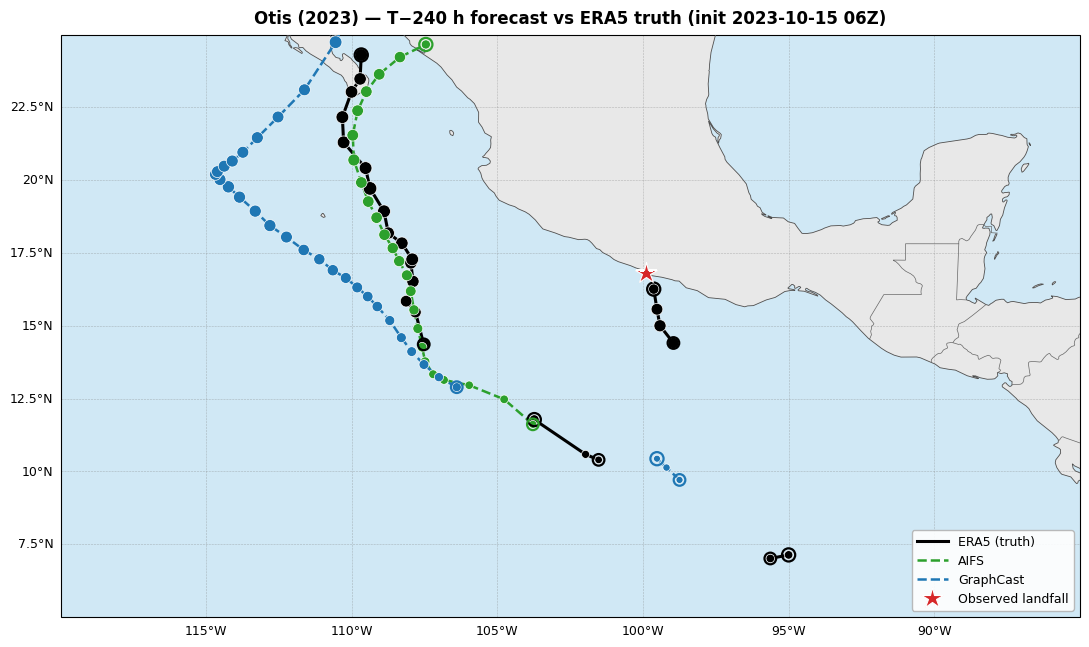

In [28]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_240, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_240, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_240,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2023) — T−240 h forecast vs ERA5 truth (init {INIT_TIMES[240]:%Y-%m-%d %H}Z)",
    save_path=OUT_DIR / "track_240h.png",
)

In [29]:
df_240 = make_error_table(240, {
    "ERA5 (truth)": era5_tracks_240,
    "AIFS":         aifs_tracks_240,
    "GraphCast":    gc_tracks_240,
})
print(f"\n=== T−240h position error (km) vs ERA5 truth ===\n")
print(df_240.to_string(index=False))


=== T−240h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-24 12Z            --               2669
  10-24 18Z            --               2604
  10-25 00Z            --               2537
  10-25 06Z          1591               2472


## Summary

**Hurricane Otis (2023)** — Eastern Pacific Category 5 landfall near Acapulco, Guerrero, MX.
One of the fastest-intensifying Atlantic/Pacific hurricanes on record; went from tropical storm
to Cat 5 in under 12 hours, making it a severe test of AI model track and intensity forecasting.

**Saved outputs in `./outputs/otis/`:**
- Forecast tracks: `aifs_{72,168,240}h.pt`, `graphcast_{72,168,240}h.pt`
- ERA5 truth tracks: `era5_{72,168,240}h.pt`
- Track plots: `track_{72,168,240}h.png`